In [1]:
# MNSIT Digit Classifier - PyTorch
import torch
import torchvision
from torchvision import transforms

In [2]:
# Data preprocessing: normalization
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Loading the dataset
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

# Printing the shape of the datasets
print(f'Training data: {len(train_dataset)} samples')
print(f'Testing data: {len(test_dataset)} samples')

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw

Training data: 60000 samples
Testing data: 10000 samples


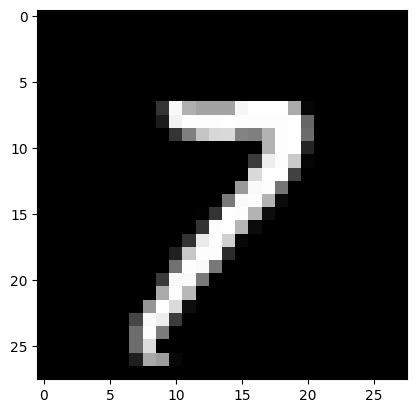

tensor(7)


In [3]:
import matplotlib.pyplot as plt
import numpy 

dataiter = iter(train_loader)
images, labels = next(dataiter) # get one batch of images and labels

plt.imshow(images[6].numpy().squeeze(), cmap='gray') # index = 0, images[6] -> 7th image in the batch
                     # numpy() -> convert tensor into numpy array
                     # squeeze() -> move unnecessary dimension - 2D image display
plt.show()

print(labels[6])

In [4]:
# define model

import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module) :
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.softmax(self.fc3(x), dim=1)
        return x

model = Net()

In [5]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training the model for 10 epochs
num_epochs = 10
for epoch in range(num_epochs):
    running_loss = 0.0
    for i, (images, labels) in enumerate(train_loader, 1): # Added enumeration to get batch number
        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward + backward + optimize
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/i}")

Epoch 1/10, Loss: 1.6559334521862998
Epoch 2/10, Loss: 1.544914650002014
Epoch 3/10, Loss: 1.5287707267539588
Epoch 4/10, Loss: 1.5197035436437074
Epoch 5/10, Loss: 1.5129048207929647
Epoch 6/10, Loss: 1.5094626964028202
Epoch 7/10, Loss: 1.5047717793409758
Epoch 8/10, Loss: 1.502566080611906
Epoch 9/10, Loss: 1.5012127552459489
Epoch 10/10, Loss: 1.4998887900604623


In [6]:
correct = 0
total = 0

with torch.no_grad(): # we do not want any gradients
    for images, labels in test_loader:
        outputs = model(images) # model predict score for 10 classes
        _, predicted = torch.max(outputs.data, 1) # for each image - find the class with highest scsore
        total += labels.size(0) # count how many samples
        correct += (predicted == labels).sum().item() # count correct predictions

accuracy = 100 * correct / total
print(f"Model accuracy on test data set : {accuracy}%")

Model accuracy on test data set : 96.31%


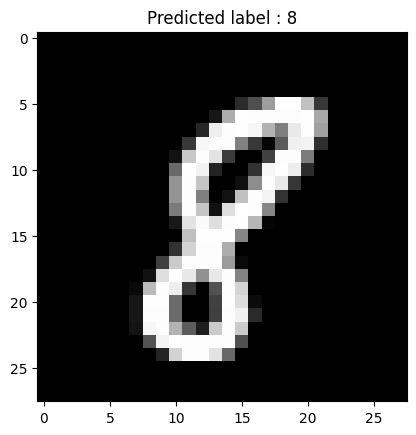

In [8]:
# Predictions :

dataiter = iter(train_loader)
images, labels = next(dataiter)

outputs = model(images[1:2])
_, predicted = torch.max(outputs.data, 1)

plt.imshow(images[1].numpy().squeeze(), cmap='gray')
plt.title(f"Predicted label : {predicted.item()}")
plt.show()